# 可视化训练日志-训练过程总体评估指标

训练模型时在`work_dirs`目录生成记录训练日志，解析其中损失函数、评估指标等信息，并可视化。

## 1. 数据加载与分类提取

将原始日志文件转换为三个独立的数据框，以便分别查看训练损失、训练准确率和验证集指标。

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 锁定绝对工作目录
WORK_DIR = '/root/LearningMMSegmentation/mmsegmentation'
os.chdir(WORK_DIR)

# 2. 配置 Matplotlib 全局中文字体
FONT_PATH = '/root/LearningMMSegmentation/SimHei.ttf'
my_font = fm.FontProperties(fname=FONT_PATH)
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

print(f"✅ 环境初始化完成。当前工作目录: {os.getcwd()}")

✅ 环境初始化完成。当前工作目录: /root/LearningMMSegmentation/mmsegmentation


## 2. 训练日志解析与数据提取

定位 `scalars.json` 评估日志文件。根据指标字段的差异，将全量数据拆分为“训练集记录”（包含 `loss`）与“验证集记录”（包含 `mIoU`）两个独立的数据框（DataFrame）。

In [2]:
# 1. 指定日志文件路径
LOG_TASK_NAME = 'CustomDataset_UNet_pipeline' 
# 【需手动修改】请前往 work_dirs/CustomDataset_UNet_pipeline 目录下查看最新生成的文件夹名称，并替换下方的时间戳
LOG_TIMESTAMP = '20260403_170557' 

LOG_PATH = os.path.join('work_dirs', LOG_TASK_NAME, LOG_TIMESTAMP, 'vis_data/scalars.json')

if not os.path.exists(LOG_PATH):
    raise FileNotFoundError(f"❌ 找不到日志文件，请核对时间戳是否正确: {LOG_PATH}")

# 2. 读取 JSON 日志并转换为 DataFrame
with open(LOG_PATH, "r", encoding="utf-8") as f:
    json_list = [json.loads(line) for line in f]
df_raw = pd.DataFrame(json_list)
print(f"✅ 成功加载全量日志数据，总计: {len(df_raw)} 条记录。")

# 3. 数据集拆分：分离训练指标与验证指标
df_train = df_raw[df_raw['loss'].notna()].copy()

# 防止因尚未进行验证而导致的 KeyError
if 'mIoU' in df_raw.columns:
    df_test = df_raw[df_raw['mIoU'].notna()].copy()
else:
    df_test = pd.DataFrame()

print(f"📊 提取【训练集】记录: {len(df_train)} 条。")
print(f"📈 提取【验证集】记录: {len(df_test)} 条。")

✅ 成功加载全量日志数据，总计: 36 条记录。
📊 提取【训练集】记录: 26 条。
📈 提取【验证集】记录: 10 条。


## 3. 数据结构预览

在进行图表绘制前，展示核心数据框的头部记录，以便核对字段名称与数值提取的正确性，防止维度错位。

In [3]:
print("--- 训练集核心指标预览 (df_train) ---")
display(df_train[['step', 'loss', 'decode.acc_seg', 'aux.acc_seg', 'lr']].head())

if not df_test.empty:
    print("\n--- 验证集核心指标预览 (df_test) ---")
    display(df_test[['step', 'mIoU', 'mDice', 'mAcc', 'aAcc']].head())
else:
    print("\n⚠️ 提示：当前日志中暂无验证集指标记录。")

--- 训练集核心指标预览 (df_train) ---


,step,loss,decode.acc_seg,aux.acc_seg,lr
0,12,2.053618,65.103256,54.072376,0.009961
1,100,0.795589,72.622192,67.343292,0.009646
2,200,0.775392,85.834373,86.575562,0.009288
4,300,0.911058,49.890709,45.835876,0.008927
5,400,0.715092,69.006653,70.160767,0.008565



--- 验证集核心指标预览 (df_test) ---


,step,mIoU,mDice,mAcc,aAcc
3,250,42.61,50.96,51.43,86.19
7,500,33.18,43.97,47.98,70.22
10,750,54.80,65.29,63.31,88.74
14,1000,40.55,52.16,60.88,69.66
17,1250,55.46,65.72,68.27,88.32


## 4. 总体评估指标可视化与图表导出

将核心评估指标分别绘制为独立的曲线图，并以 300 DPI 的高分辨率格式统一导出至独立的结果文件夹中，便于后续撰写实验报告。

### 📂4.1 创建图表保存目录

In [4]:
# 定义你要保存的文件夹绝对路径
save_dir = '/root/LearningMMSegmentation/Learning/Training Log Pictures'

# 检查文件夹是否存在，不存在则自动创建
os.makedirs(save_dir, exist_ok=True)
print(f"📁 准备就绪！图片将保存至: {save_dir}\n")

📁 准备就绪！图片将保存至: /root/LearningMMSegmentation/Learning/Training Log Pictures



### 📈4.2 图 1：训练集损失函数 (Loss)

NameError: name 'SAVE_DIR' is not defined

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei


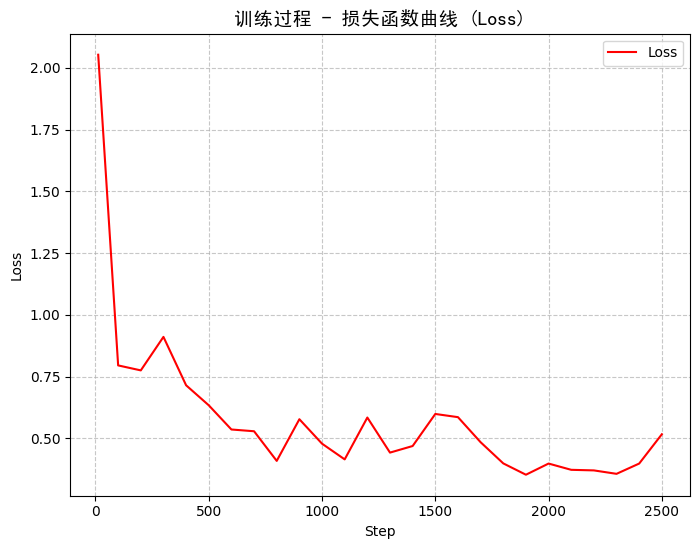

In [5]:
plt.figure(figsize=(8, 6))
plt.plot(df_train['step'], df_train['loss'], label='Loss', color='red')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('训练过程 - 损失函数曲线 (Loss)', fontproperties=my_font, fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 保存第一张图 (bbox_inches='tight' 可以消除图片边缘多余的白边)
loss_path = os.path.join(SAVE_DIR, '1_Overall_Loss_Curve.png')
plt.savefig(loss_path, dpi=300, bbox_inches='tight') 
plt.show()

### 📈4.3 图 2：训练集像素准确率 (Accuracy)

NameError: name 'SAVE_DIR' is not defined

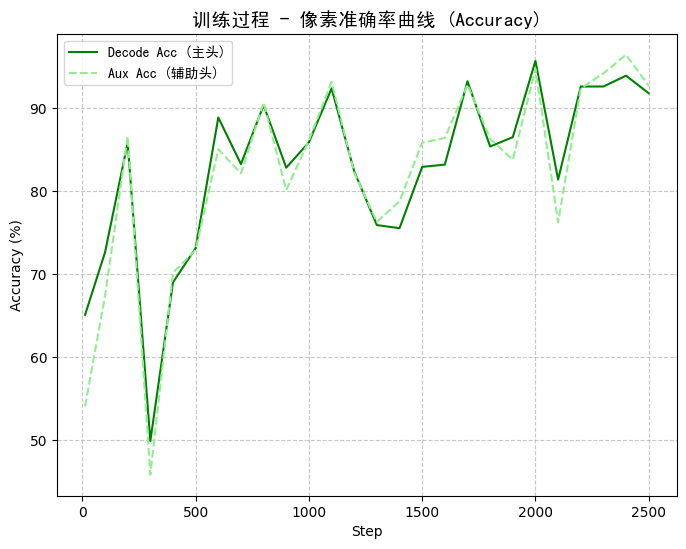

In [6]:
plt.figure(figsize=(8, 6))
plt.plot(df_train['step'], df_train['decode.acc_seg'], label='Decode Acc (主头)', color='green')
plt.plot(df_train['step'], df_train['aux.acc_seg'], label='Aux Acc (辅助头)', color='lightgreen', linestyle='--')
plt.xlabel('Step')
plt.ylabel('Accuracy (%)')
plt.title('训练过程 - 像素准确率曲线 (Accuracy)', fontproperties=my_font, fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(prop=my_font)

acc_path = os.path.join(SAVE_DIR, '2_Overall_Accuracy_Curve.png')
plt.savefig(acc_path, dpi=300, bbox_inches='tight')
plt.show()

### 4.4 图 3：验证集平均交并比 (mIoU)

NameError: name 'SAVE_DIR' is not defined

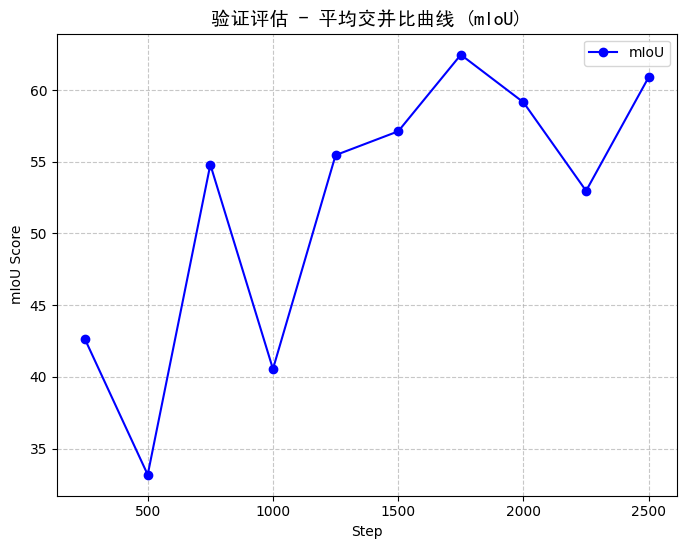

In [7]:
plt.figure(figsize=(8, 6))
if not df_test.empty:
    plt.plot(df_test['step'], df_test['mIoU'], label='mIoU', color='blue', marker='o', markersize=6)
    plt.xlabel('Step')
    plt.ylabel('mIoU Score')
    plt.title('验证评估 - 平均交并比曲线 (mIoU)', fontproperties=my_font, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
else:
    plt.text(0.5, 0.5, '暂无验证集数据', ha='center', va='center', fontproperties=my_font, fontsize=16)
    plt.title('验证评估 - mIoU 曲线 (无数据)', fontproperties=my_font)

miou_path = os.path.join(SAVE_DIR, '3_Overall_mIoU_Curve.png')
plt.savefig(miou_path, dpi=300, bbox_inches='tight')
plt.show()